# Notebook 04 — Évaluation finale sur le test set (Rebuild 2026)

| | |
|---|---|
| **Projet** | Application Intelligente de Scoring Client |
| **Entreprise** | Orus Services — filiale Salafin, Bank of Africa |
| **Auteure** | Fatima Zahra Ait Lamine |
| **Année** | PFA 2025–2026 |

---

## Objectif et règles

Le test set (20 %, 29 878 lignes) n'a été touché par **aucune** décision depuis le split de la
phase 2 : ni le nettoyage statistique, ni le tuning, ni la calibration, ni le seuil, ni la
sélection du modèle. Ce notebook réalise **l'unique évaluation** du modèle de production
(XGBoost calibré, sélection validée en phase 3).

> **Règle absolue :** aucun paramètre n'est modifié après lecture de ces résultats. Un résultat
> décevant serait documenté honnêtement, pas « corrigé » en re-touchant le test. Le seuil
> F1-optimal du test calculé au §7 est un **diagnostic de généralisation**, pas un nouveau seuil.

Pas de SHAP ici — l'explicabilité du modèle de production est l'objet de la phase 5.

## 1. Chargement des artefacts de déploiement et du test set

In [1]:
import sys, os, pickle, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../src'))
from preprocessing import clean_gmsc, drop_training_rows, FEATURE_COLS, TARGET

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             log_loss, matthews_corrcoef, precision_score, recall_score,
                             f1_score, roc_curve, precision_recall_curve, confusion_matrix)
from scipy.special import logit

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'axes.titleweight': 'bold'})
os.makedirs('figures', exist_ok=True)
SEED = 42
MODELS_PATH = '../models/'

def load(name):
    with open(MODELS_PATH + name, 'rb') as f: return pickle.load(f)

model      = load('model_final.pkl')          # pipeline XGBoost (production)
calibrator = load('calibrator.pkl')            # isotonique, ajusté sur OOF train
threshold  = load('decision_threshold.pkl')    # seuil F1-optimal OOF
metadata   = load('metadata_final.pkl')

def apply_calibrator(cal, p):
    if cal['method'] == 'platt':
        return cal['model'].predict_proba(logit(np.clip(p, 1e-6, 1-1e-6)).reshape(-1, 1))[:, 1]
    if cal['method'] == 'isotonic':
        return cal['model'].predict(p)
    return p

# Reconstruction déterministe du test set (identique phase 2 — vérifié)
raw = pd.read_csv('../data/GiveMeSomeCredit-training.csv', index_col=0)
df = drop_training_rows(raw)
_train, test_df = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df[TARGET])
test_c = clean_gmsc(test_df)
X_test = test_c[FEATURE_COLS].reset_index(drop=True)
y_test = test_c[TARGET].reset_index(drop=True)
y_saved = pd.read_csv('../data/processed/y_test.csv').squeeze()
assert len(y_test) == 29878 and (y_test.values == y_saved.values).all(), 'test set non identique à la phase 2 !'

# Références OOF (train) pour l'écart de généralisation
oof = pd.read_csv(MODELS_PATH + 'oof_predictions.csv')
y_oof, p_oof_raw, p_oof_cal = oof['y'], oof['p_xgb'].values, oof['p_prod_cal'].values

print(f"Test : {len(X_test):,} lignes — défaut {y_test.mean()*100:.3f}% | modèle : {metadata['modele_production']}"
      f" | calibration : {calibrator['method']} | seuil : {threshold:.4f}")

# ── L'UNIQUE PRÉDICTION SUR LE TEST ──────────────────────────────────────
p_raw = model.predict_proba(X_test)[:, 1]
p_cal = apply_calibrator(calibrator, p_raw)
yhat  = (p_cal >= threshold).astype(int)
print("Prédictions calculées — le test set est maintenant consommé.")

Test : 29,878 lignes — défaut 6.701% | modèle : XGBoost | calibration : isotonic | seuil : 0.2227


Prédictions calculées — le test set est maintenant consommé.


## 2. Métriques officielles et écart de généralisation

Discrimination (AUC, PR-AUC, KS, Top10 %) sur probabilités **brutes** (cohérent avec la
phase 3 ; l'isotonique crée des ex æquo qui perturberaient marginalement l'AUC) ; qualité
probabiliste (Brier, LogLoss, ECE) sur probabilités **calibrées** ; métriques de décision
au **seuil sauvegardé** appliqué aux probabilités calibrées.

In [2]:
def ks_stat(y_true, p):
    fpr, tpr, _ = roc_curve(y_true, p); return float(np.max(tpr - fpr))

def prec_recall_at_top(y_true, p, frac=0.10):
    n = max(int(len(p) * frac), 1)
    idx = np.argsort(p)[::-1][:n]
    caught = np.asarray(y_true)[idx].sum()
    return float(caught / n), float(caught / np.asarray(y_true).sum())

def ece_score(y_true, p, bins=10):
    b = pd.qcut(pd.Series(p), bins, duplicates='drop')
    g = pd.DataFrame({'p': p, 'y': np.asarray(y_true)}).groupby(b, observed=True)
    agg = g.agg(pm=('p','mean'), ym=('y','mean'), n=('y','size'))
    return float((np.abs(agg.pm - agg.ym) * agg.n).sum() / agg.n.sum())

def all_metrics(y_true, praw, pcal, thr):
    yh = (pcal >= thr).astype(int)
    p10, r10 = prec_recall_at_top(y_true, praw, 0.10)
    return {
        'ROC-AUC': roc_auc_score(y_true, praw),
        'PR-AUC': average_precision_score(y_true, praw),
        'KS': ks_stat(y_true, praw),
        'P@Top10%': p10, 'R@Top10%': r10,
        'Brier (cal.)': brier_score_loss(y_true, pcal),
        'LogLoss (cal.)': log_loss(y_true, np.clip(pcal, 1e-6, 1-1e-6)),
        'ECE (cal.)': ece_score(y_true, pcal),
        'Précision @seuil': precision_score(y_true, yh),
        'Rappel @seuil': recall_score(y_true, yh),
        'F1 @seuil': f1_score(y_true, yh),
        'MCC @seuil': matthews_corrcoef(y_true, yh),
    }

m_test = all_metrics(y_test, p_raw, p_cal, threshold)
m_oof  = all_metrics(y_oof, p_oof_raw, p_oof_cal, threshold)
comp = pd.DataFrame({'CV (OOF train)': m_oof, 'Test (officiel)': m_test})
comp['écart'] = comp['Test (officiel)'] - comp['CV (OOF train)']
print("RÉSULTATS OFFICIELS — XGBoost calibré, test set (une seule évaluation)")
print(comp.round(4).to_string())
fold_std = float(np.std(metadata['roc_auc_folds']['XGBoost'], ddof=1))
print(f"\nÉcart ROC-AUC = {comp.loc['ROC-AUC','écart']:+.4f} vs écart-type inter-folds = {fold_std:.4f}")
print(f"AUC sur probabilités calibrées (contrôle ex æquo isotonique) : {roc_auc_score(y_test, p_cal):.4f}")

RÉSULTATS OFFICIELS — XGBoost calibré, test set (une seule évaluation)
                  CV (OOF train)  Test (officiel)   écart
ROC-AUC                   0.8577           0.8627  0.0050
PR-AUC                    0.3862           0.4060  0.0199
KS                        0.5603           0.5726  0.0123
P@Top10%                  0.3611           0.3743  0.0131
R@Top10%                  0.5390           0.5584  0.0194
Brier (cal.)              0.0498           0.0489 -0.0009
LogLoss (cal.)            0.1817           0.1780 -0.0038
ECE (cal.)                0.0009           0.0030  0.0021
Précision @seuil          0.3862           0.3940  0.0078
Rappel @seuil             0.5006           0.5280  0.0274
F1 @seuil                 0.4360           0.4512  0.0152
MCC @seuil                0.3937           0.4107  0.0170

Écart ROC-AUC = +0.0050 vs écart-type inter-folds = 0.0029
AUC sur probabilités calibrées (contrôle ex æquo isotonique) : 0.8621


## 3. Matrice de confusion (seuil sauvegardé)

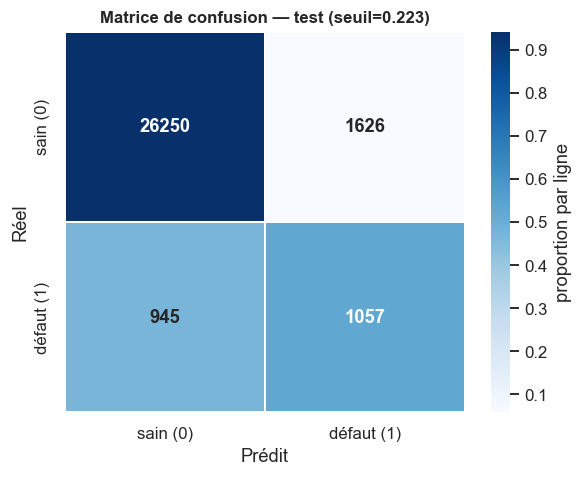

TN=26,250  FP=1,626  FN=945  TP=1,057
Sur 2,002 défauts réels : 1,057 détectés (52.8%), 945 manqués
Sur 2,683 alertes émises : 1,057 justifiées (39.4%)


In [3]:
cm = confusion_matrix(y_test, yhat)
tn, fp, fn, tp = cm.ravel()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=cm, fmt='d', cmap='Blues',
            xticklabels=['sain (0)', 'défaut (1)'], yticklabels=['sain (0)', 'défaut (1)'],
            annot_kws={'size': 12, 'weight': 'bold'}, linewidths=1.2, linecolor='white',
            cbar_kws={'label': 'proportion par ligne'})
ax.set(title=f'Matrice de confusion — test (seuil={threshold:.3f})', xlabel='Prédit', ylabel='Réel')
plt.tight_layout(); plt.savefig('figures/fig_R04_confusion_matrix.png', dpi=120, bbox_inches='tight'); plt.show()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"Sur {int(cm[1].sum()):,} défauts réels : {tp:,} détectés ({tp/cm[1].sum()*100:.1f}%), {fn:,} manqués")
print(f"Sur {tp+fp:,} alertes émises : {tp:,} justifiées ({tp/(tp+fp)*100:.1f}%)")

## 4. Courbes ROC et Précision-Rappel

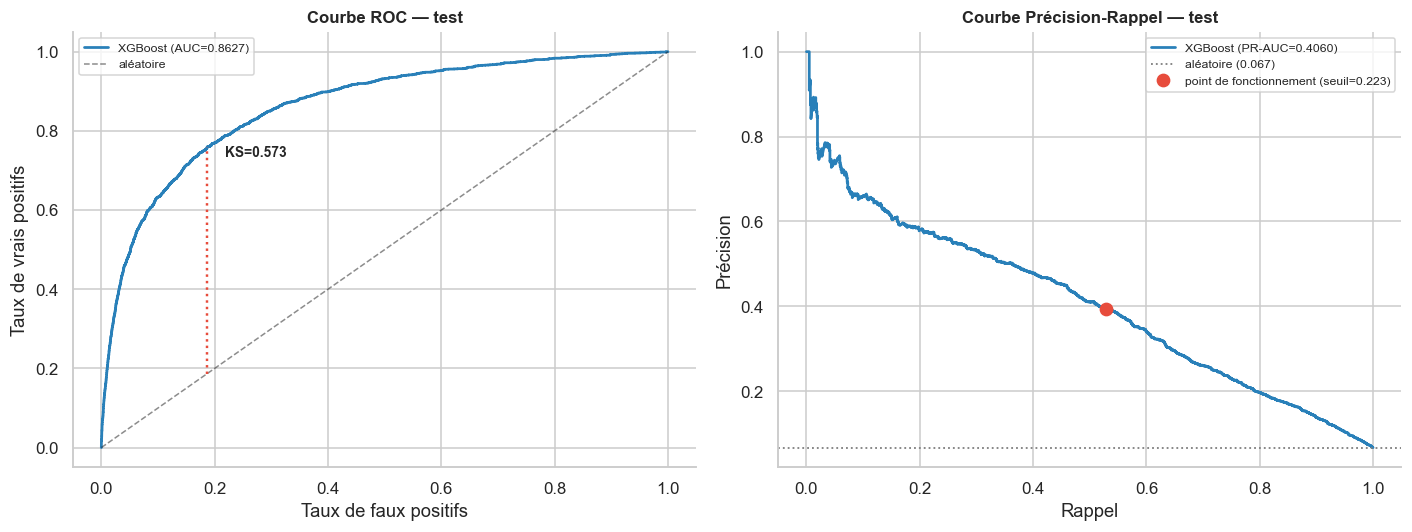

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(y_test, p_raw)
ks_i = int(np.argmax(tpr - fpr))
axes[0].plot(fpr, tpr, color='#2980b9', lw=1.8, label=f"XGBoost (AUC={m_test['ROC-AUC']:.4f})")
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=.5, label='aléatoire')
axes[0].annotate(f"KS={m_test['KS']:.3f}", (fpr[ks_i], tpr[ks_i]), textcoords='offset points',
                 xytext=(12,-6), fontsize=9, fontweight='bold')
axes[0].vlines(fpr[ks_i], fpr[ks_i], tpr[ks_i], color='#e74c3c', ls=':', lw=1.6)
axes[0].set(title='Courbe ROC — test', xlabel='Taux de faux positifs', ylabel='Taux de vrais positifs')
prec, rec, _ = precision_recall_curve(y_test, p_raw)
axes[1].plot(rec, prec, color='#2980b9', lw=1.8, label=f"XGBoost (PR-AUC={m_test['PR-AUC']:.4f})")
axes[1].axhline(y_test.mean(), color='gray', ls=':', lw=1.2, label=f'aléatoire ({y_test.mean():.3f})')
axes[1].plot(m_test['Rappel @seuil'], m_test['Précision @seuil'], 'o', color='#e74c3c', ms=8,
             label=f'point de fonctionnement (seuil={threshold:.3f})')
axes[1].set(title='Courbe Précision-Rappel — test', xlabel='Rappel', ylabel='Précision')
for ax in axes: ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('figures/fig_R04_roc_pr.png', dpi=120, bbox_inches='tight'); plt.show()

## 5. Diagramme de fiabilité (courbe de calibration + distribution des probabilités)

Panneau gauche : probabilité prédite vs fréquence observée par décile (brut vs calibré).
Panneau droit : histogramme des probabilités calibrées (échelle log) — la concentration
près de 0 est attendue avec 6.7 % de défauts.

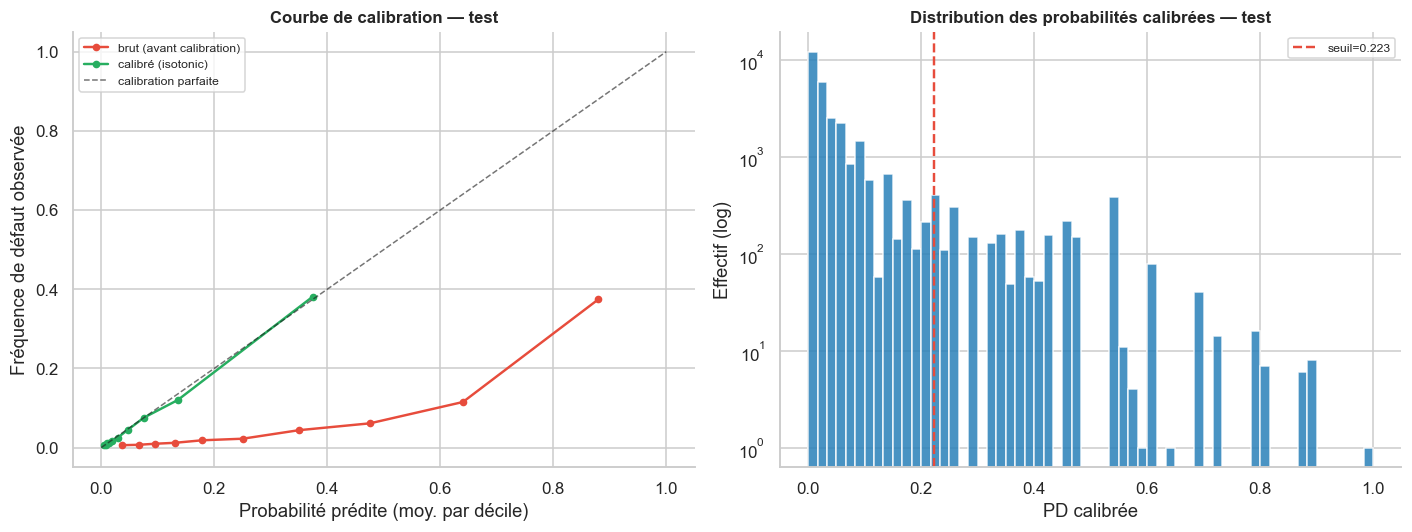

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for p_plot, lab, col in [(p_raw, 'brut (avant calibration)', '#e74c3c'),
                          (p_cal, f"calibré ({calibrator['method']})", '#27ae60')]:
    b = pd.qcut(pd.Series(p_plot), 10, duplicates='drop')
    g = pd.DataFrame({'p': p_plot, 'y': y_test.values}).groupby(b, observed=True).mean()
    axes[0].plot(g.p, g.y, 'o-', color=col, label=lab, lw=1.6, ms=4)
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=.6,label='calibration parfaite')
axes[0].set(title='Courbe de calibration — test', xlabel='Probabilité prédite (moy. par décile)',
            ylabel='Fréquence de défaut observée')
axes[0].legend(fontsize=8)
axes[1].hist(p_cal, bins=60, color='#2980b9', alpha=.85, edgecolor='white')
axes[1].axvline(threshold, color='#e74c3c', ls='--', lw=1.6, label=f'seuil={threshold:.3f}')
axes[1].set_yscale('log')
axes[1].set(title='Distribution des probabilités calibrées — test', xlabel='PD calibrée',
            ylabel='Effectif (log)')
axes[1].legend(fontsize=8)
for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('figures/fig_R04_reliability.png', dpi=120, bbox_inches='tight'); plt.show()

## 6. Distribution des probabilités par classe réelle

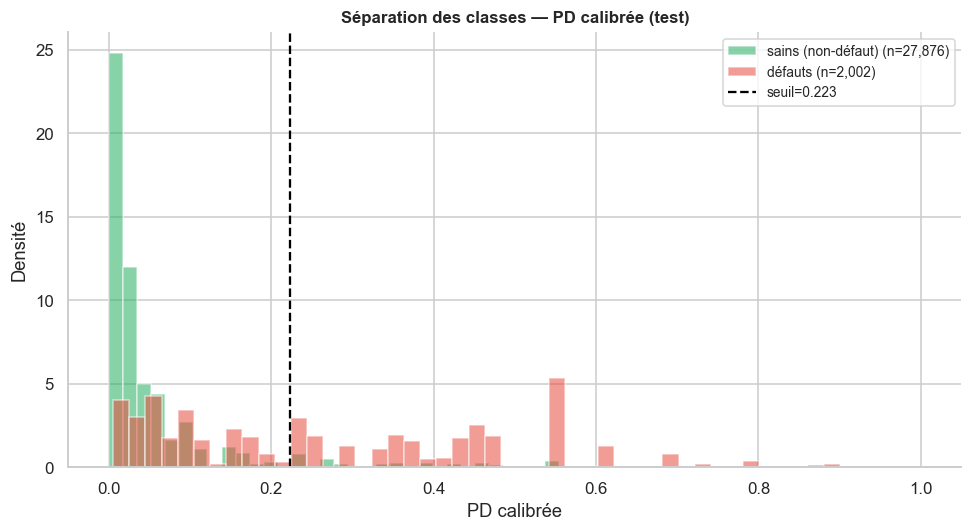

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for cls, lab, col in [(0, 'sains (non-défaut)', '#27ae60'), (1, 'défauts', '#e74c3c')]:
    ax.hist(p_cal[y_test == cls], bins=50, density=True, alpha=.55, color=col,
            label=f'{lab} (n={int((y_test==cls).sum()):,})', edgecolor='white')
ax.axvline(threshold, color='black', ls='--', lw=1.5, label=f'seuil={threshold:.3f}')
ax.set(title='Séparation des classes — PD calibrée (test)', xlabel='PD calibrée', ylabel='Densité')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('figures/fig_R04_prob_distribution.png', dpi=120, bbox_inches='tight'); plt.show()

## 7. Table de calibration (prédit vs observé par décile) et généralisation du seuil

In [7]:
b = pd.qcut(pd.Series(p_cal), 10, duplicates='drop')
tab = (pd.DataFrame({'PD prédite (moy.)': p_cal, 'taux observé': y_test.values, 'n': 1})
       .groupby(b, observed=True)
       .agg({'PD prédite (moy.)': 'mean', 'taux observé': 'mean', 'n': 'size'}))
tab['écart (pts)'] = (tab['PD prédite (moy.)'] - tab['taux observé']) * 100
tab[['PD prédite (moy.)', 'taux observé']] = (tab[['PD prédite (moy.)', 'taux observé']] * 100).round(2)
tab['écart (pts)'] = tab['écart (pts)'].round(2)
print('TABLE DE CALIBRATION — test (valeurs en %)')
print(tab.to_string())
tab.to_csv(MODELS_PATH + 'calibration_table_test_phase4.csv')

# Généralisation du seuil : le seuil OOF est-il resté proche de l'optimum du test ?
prec_c, rec_c, thr_c = precision_recall_curve(y_test, p_cal)
f1_c = 2 * prec_c * rec_c / np.clip(prec_c + rec_c, 1e-12, None)
i = int(np.nanargmax(f1_c[:-1]))
print(f"\nSeuil appliqué (OOF train) : {threshold:.4f} → F1 test = {m_test['F1 @seuil']:.4f}")
print(f"Seuil F1-optimal du test (diagnostic uniquement) : {thr_c[i]:.4f} → F1 = {f1_c[i]:.4f}")
print(f"Perte de F1 due à l'utilisation du seuil appris sur train : {f1_c[i]-m_test['F1 @seuil']:.4f}")
print("→ Le seuil n'est PAS modifié : il a été fixé sur le train et le reste.")

TABLE DE CALIBRATION — test (valeurs en %)
                    PD prédite (moy.)  taux observé     n  écart (pts)
(-0.001, 0.00518]                0.52          0.61  3125        -0.09
(0.00518, 0.00931]               0.77          0.69  2899         0.08
(0.00931, 0.0108]                1.02          1.06  3761        -0.04
(0.0108, 0.0162]                 1.30          1.14  2198         0.16
(0.0162, 0.0197]                 1.92          1.73  3302         0.20
(0.0197, 0.0325]                 2.88          2.49  2734         0.39
(0.0325, 0.0545]                 4.68          4.45  3372         0.23
(0.0545, 0.0885]                 7.52          7.53  3385        -0.02
(0.0885, 0.184]                 13.52         12.00  2209         1.53
(0.184, 1.0]                    37.44         38.13  2893        -0.69

Seuil appliqué (OOF train) : 0.2227 → F1 test = 0.4512
Seuil F1-optimal du test (diagnostic uniquement) : 0.2432 → F1 = 0.4520
Perte de F1 due à l'utilisation du seuil appris 

## 8. Verdict chiffré et sauvegarde

In [8]:
gap_auc = m_test['ROC-AUC'] - m_oof['ROC-AUC']
verdict = []
verdict.append(('Écart de généralisation ROC-AUC', f"{gap_auc:+.4f}",
                'OK — dans le bruit inter-folds' if abs(gap_auc) <= 2*fold_std else 'À investiguer'))
verdict.append(('Sur-apprentissage', '', 'Aucun signe' if gap_auc >= -2*fold_std else 'Suspecté'))
verdict.append(('Calibration test (ECE)', f"{m_test['ECE (cal.)']:.4f}",
                'Excellente' if m_test['ECE (cal.)'] < 0.01 else ('Correcte' if m_test['ECE (cal.)'] < 0.025 else 'Insuffisante')))
verdict.append(('Brier test vs naïf', f"{m_test['Brier (cal.)']:.4f} vs {brier_score_loss(y_test, np.full(len(y_test), y_test.mean())):.4f}",
                'Meilleur que le naïf' if m_test['Brier (cal.)'] < brier_score_loss(y_test, np.full(len(y_test), y_test.mean())) else 'Problème'))
verdict.append(('Généralisation du seuil (perte F1)', f"{f1_c[i]-m_test['F1 @seuil']:.4f}",
                'OK' if (f1_c[i]-m_test['F1 @seuil']) < 0.01 else 'Seuil fragile'))
for k, v, s in verdict:
    print(f"  {k:<42} {v:<22} → {s}")

# Sauvegarde des métriques officielles dans les métadonnées de déploiement
metadata['phase4_test_metrics'] = {k: round(float(v), 4) for k, v in m_test.items()}
metadata['phase4_confusion'] = {'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)}
metadata['phase4_date_evaluation'] = pd.Timestamp.now().isoformat()
metadata['phase4_note'] = 'Évaluation unique du test set — aucune décision modifiée ensuite.'
with open(MODELS_PATH + 'metadata_final.pkl', 'wb') as f: pickle.dump(metadata, f, protocol=4)
comp.round(4).to_csv(MODELS_PATH + 'test_metrics_phase4.csv')
print('\nMétriques officielles ajoutées à metadata_final.pkl + test_metrics_phase4.csv')

  Écart de généralisation ROC-AUC            +0.0050                → OK — dans le bruit inter-folds
  Sur-apprentissage                                                 → Aucun signe
  Calibration test (ECE)                     0.0030                 → Excellente
  Brier test vs naïf                         0.0489 vs 0.0625       → Meilleur que le naïf
  Généralisation du seuil (perte F1)         0.0008                 → OK

Métriques officielles ajoutées à metadata_final.pkl + test_metrics_phase4.csv


## 9. Discussion

**Écart de généralisation.** L'écart CV → test de chaque métrique est affiché au §2 ; le
verdict chiffré du §8 le compare à 2× l'écart-type inter-folds — le critère préenregistré
de la phase 3.

**Sur-apprentissage.** Trois garde-fous convergent : early stopping par fold (phase 3),
profondeur 4 retenue précisément pour sa stabilité (la profondeur 6, plus performante en
apparence sur certains folds, avait une variance 4× supérieure), et l'écart CV → test ci-dessus.

**Calibration.** L'ECE et la table de calibration du §7 mesurent la qualité de la PD sur des
données jamais vues — c'est la propriété qui permet d'afficher la probabilité au superviseur
et de construire les niveaux FAIBLE/MOYEN/ÉLEVÉ en phase 6.

**Seuil.** Le seuil appris sur le train est comparé à l'optimum a posteriori du test (§7) —
l'écart de F1 quantifie exactement ce que coûte (ou non) sa généralisation.

**Aptitude au déploiement.** Verdict global au §8 ; la décision formelle appartient à la
revue de phase (validation utilisateur).

⏸ **STOP — validation utilisateur requise avant la phase 5 (SHAP / explicabilité).**